[Set Up](#set-up-data)
<br>
[Variable Glossary](#Variable-Glossary)
<br>
[Visualizing each feature](#Visualizing-each-feature)
<br>
[Correlation Matricies](#correlation-matricies)
<br>
[Crosstabs](#crosstabs)
<br>
[Data Cleaning](#correlation-matricies)
<br>
[Data Prep](#moving-on-to-the-rest-of-the-data-prep)
<br>
[Simple Logistic Regression](#logistic-regression)
<br>
[Logistic Regression with Lasso](#lasso)
<br>
[RandomForest](#random-forest)
<br>
[SMOTE](#smote)
<br>
[SVM](#svm)
<br>
[XGBoost](#xgboost)
<br>

# Set Up Data

**Data:**
I am using open source data from Kaggle found [here](https://www.kaggle.com/code/minaremon39/celiac-disease-prediction/notebook)

First, install dependencies

In [4]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [5]:
import sys
%pip install "numpy>=1.21.6,<2.0.0" "pandas>=1.5.0" "scikit-learn>=1.3.0" "xgboost>=1.7.0" "shap>=0.42.0" "matplotlib>=3.7.0" "seaborn>=0.12.0"

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
from pandas import read_csv
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy.stats import chi2_contingency

First, reading in the data from the CSV file <br>
If you are trying to run this code, make sure you have downloaded the CSV file

In [7]:
filename = "celiac_disease_lab_data.csv"
df = pd.read_csv(filename)
df.head()

,Age,Gender,Diabetes,Diabetes_Type,Diarrhea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Marsh,cd_type,Disease_Diagnose
0,10,Male,Yes,Type 1,inflammatory,yes,PSS,no,no,1.30,10.0,1.00,marsh type 0,potential,yes
1,9,Male,Yes,Type 1,fatty,yes,PSS,no,no,1.50,12.5,1.30,marsh type 3a,atypical,yes
2,8,Female,Yes,Type 1,watery,yes,Variant,yes,yes,0.40,8.0,0.50,marsh type 1,latent,yes
3,10,Male,Yes,Type 1,watery,yes,PSS,no,no,0.98,9.0,0.66,marsh type 3a,silent,yes
4,9,Male,Yes,Type 1,fatty,yes,PSS,no,no,1.00,10.5,1.10,marsh type 1,latent,yes


In [8]:
df.dtypes

Age                   int64
Gender               object
Diabetes             object
Diabetes_Type        object
Diarrhea             object
Abdominal            object
Short_Stature        object
Sticky_Stool         object
Weight_loss          object
IgA                 float64
IgG                 float64
IgM                 float64
Marsh                object
cd_type              object
Disease_Diagnose     object
dtype: object

In [9]:
df.isna().sum()

Age                   0
Gender                0
Diabetes              0
Diabetes_Type       418
Diarrhea              0
Abdominal             0
Short_Stature         0
Sticky_Stool          0
Weight_loss           0
IgA                   0
IgG                   0
IgM                   0
Marsh                 0
cd_type               0
Disease_Diagnose      0
dtype: int64

This means there's 418 missing values in the Diabetes_Type variable that we will have to handle. There aren't any values missing from the .csv file, so something must have happened when reading the data in. We will replace these NA values with 0s since they represent people without diabetes.

In [10]:
df["Diabetes_Type"] = df["Diabetes_Type"].fillna(0)

In [11]:
df.duplicated().sum()

1557

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.shape

(649, 15)

Yikes - there were a lot of duplicates in this dataset. We now have a much smaller dataset than when we started.

# Variable Glossary

In [14]:
# starting with age
df['Age'].describe()

count    649.000000
mean      12.636364
std        7.350168
min        1.000000
25%        8.000000
50%       10.000000
75%       15.000000
max       35.000000
Name: Age, dtype: float64

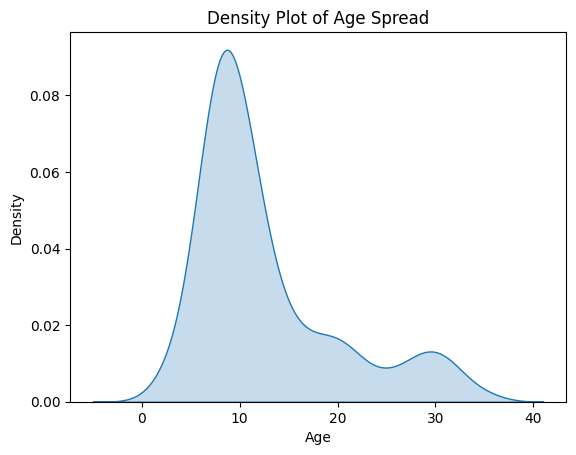

In [15]:
sns.kdeplot(df['Age'], fill=True)

plt.title('Density Plot of Age Spread')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

In [16]:
df['IgA'].describe()

count    649.000000
mean       1.401387
std        1.092107
min        0.340000
25%        0.980000
50%        1.100000
75%        1.800000
max        9.000000
Name: IgA, dtype: float64

In [17]:
df['IgG'].describe()

count    649.000000
mean      10.130354
std        1.963734
min        5.000000
25%        9.000000
50%       10.000000
75%       12.000000
max       15.300000
Name: IgG, dtype: float64

In [18]:
df['IgM'].describe()

count    649.000000
mean       1.230200
std        0.440298
min        0.500000
25%        1.000000
50%        1.100000
75%        1.500000
max        2.700000
Name: IgM, dtype: float64

In [19]:
df['Marsh'].describe()

count      649
unique       7
top       none
freq       133
Name: Marsh, dtype: object

In [20]:
df['Disease_Diagnose'].describe()

count     649
unique      2
top       yes
freq      504
Name: Disease_Diagnose, dtype: object

In [21]:
df['Marsh'].describe()

count      649
unique       7
top       none
freq       133
Name: Marsh, dtype: object

In [22]:
df['Diabetes'].describe()

count     649
unique      2
top       Yes
freq      546
Name: Diabetes, dtype: object

In [23]:
df['Diabetes_Type'].describe()

count        649
unique         3
top       Type 1
freq         503
Name: Diabetes_Type, dtype: object

In [24]:
df['Diarrhea'].describe()

count        649
unique         3
top       watery
freq         227
Name: Diarrhea, dtype: object

In [25]:
df['Abdominal'].describe()

count     649
unique      2
top       yes
freq      533
Name: Abdominal, dtype: object

In [26]:
df['Sticky_Stool'].describe()

count     649
unique      2
top       yes
freq      517
Name: Sticky_Stool, dtype: object

In [27]:
df['Short_Stature'].describe()

count     649
unique      3
top       PSS
freq      287
Name: Short_Stature, dtype: object

In [28]:
df['Weight_loss'].describe()

count     649
unique      2
top       yes
freq      434
Name: Weight_loss, dtype: object

In [29]:
df['cd_type'].describe()

count          649
unique           6
top       atypical
freq           154
Name: cd_type, dtype: object

# Visualizing each feature

Starting with numeric features. Histograms showed the most about the data.


In [32]:
df_num = df.select_dtypes(include=[np.number])
df_cat = df.select_dtypes(include=['object'])

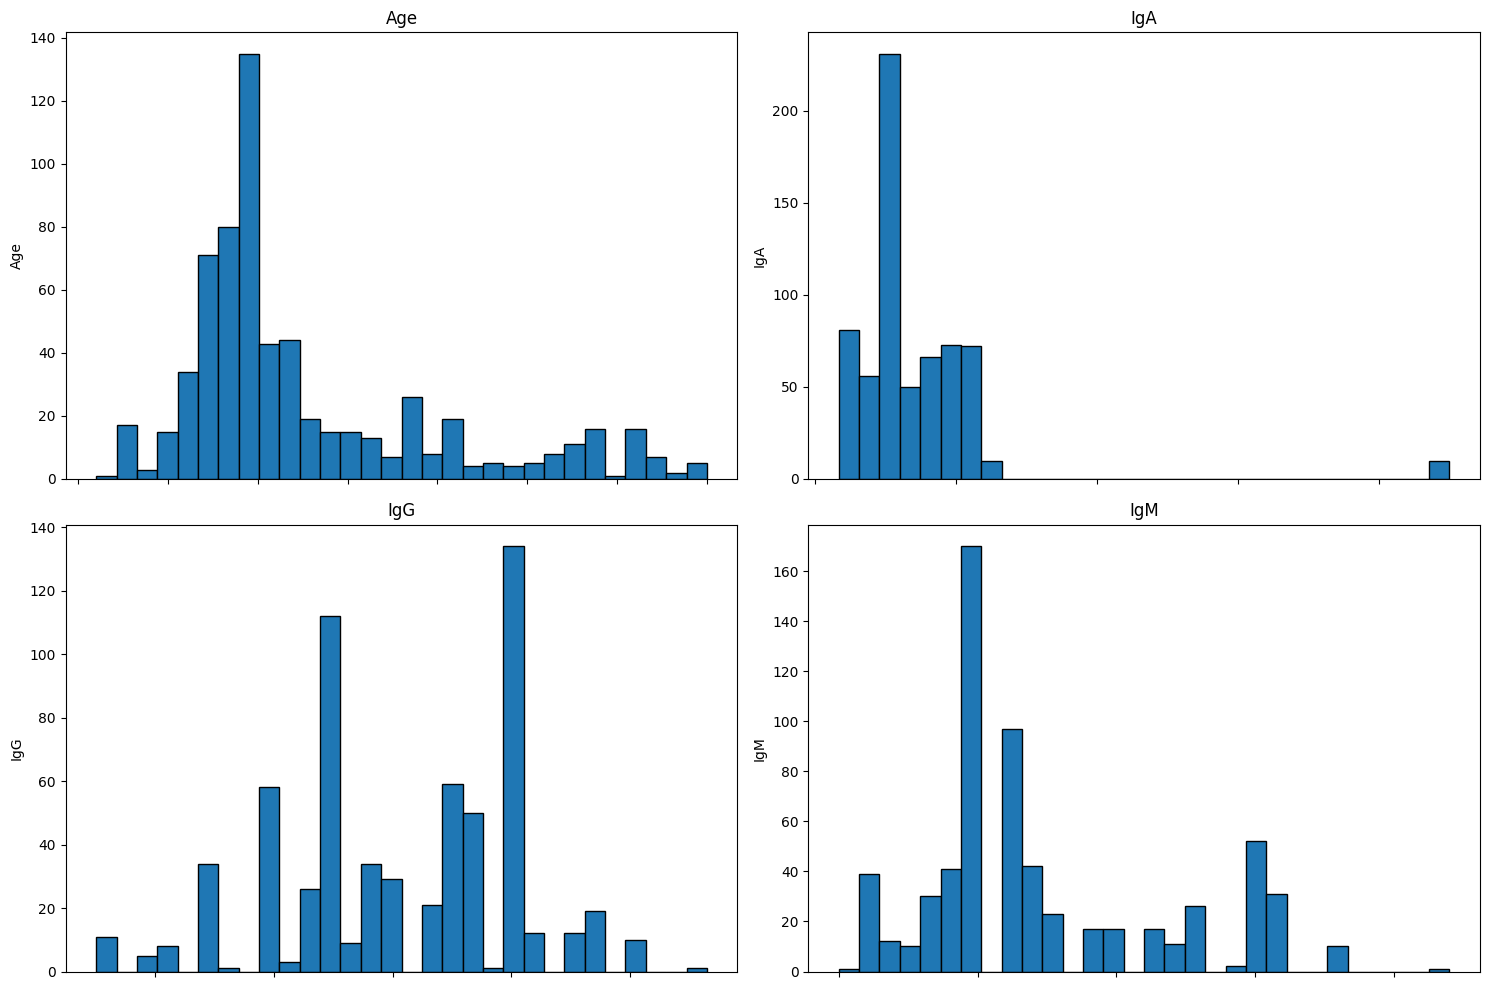

In [33]:
n_features = len(df_num.columns)
ncols = 2
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))   
axes = axes.flatten()

for i, col in enumerate(df_num.columns):
    #axes[i].boxplot(df_num[col])
    #axes[i].scatter(range(len(df_num[col])), df_num[col], alpha=0.5)
    axes[i].hist(df_num[col].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(col)  
    axes[i].set_xticklabels('')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Next, visualize the spread of the categorical variables. We're going to plot using count plots.

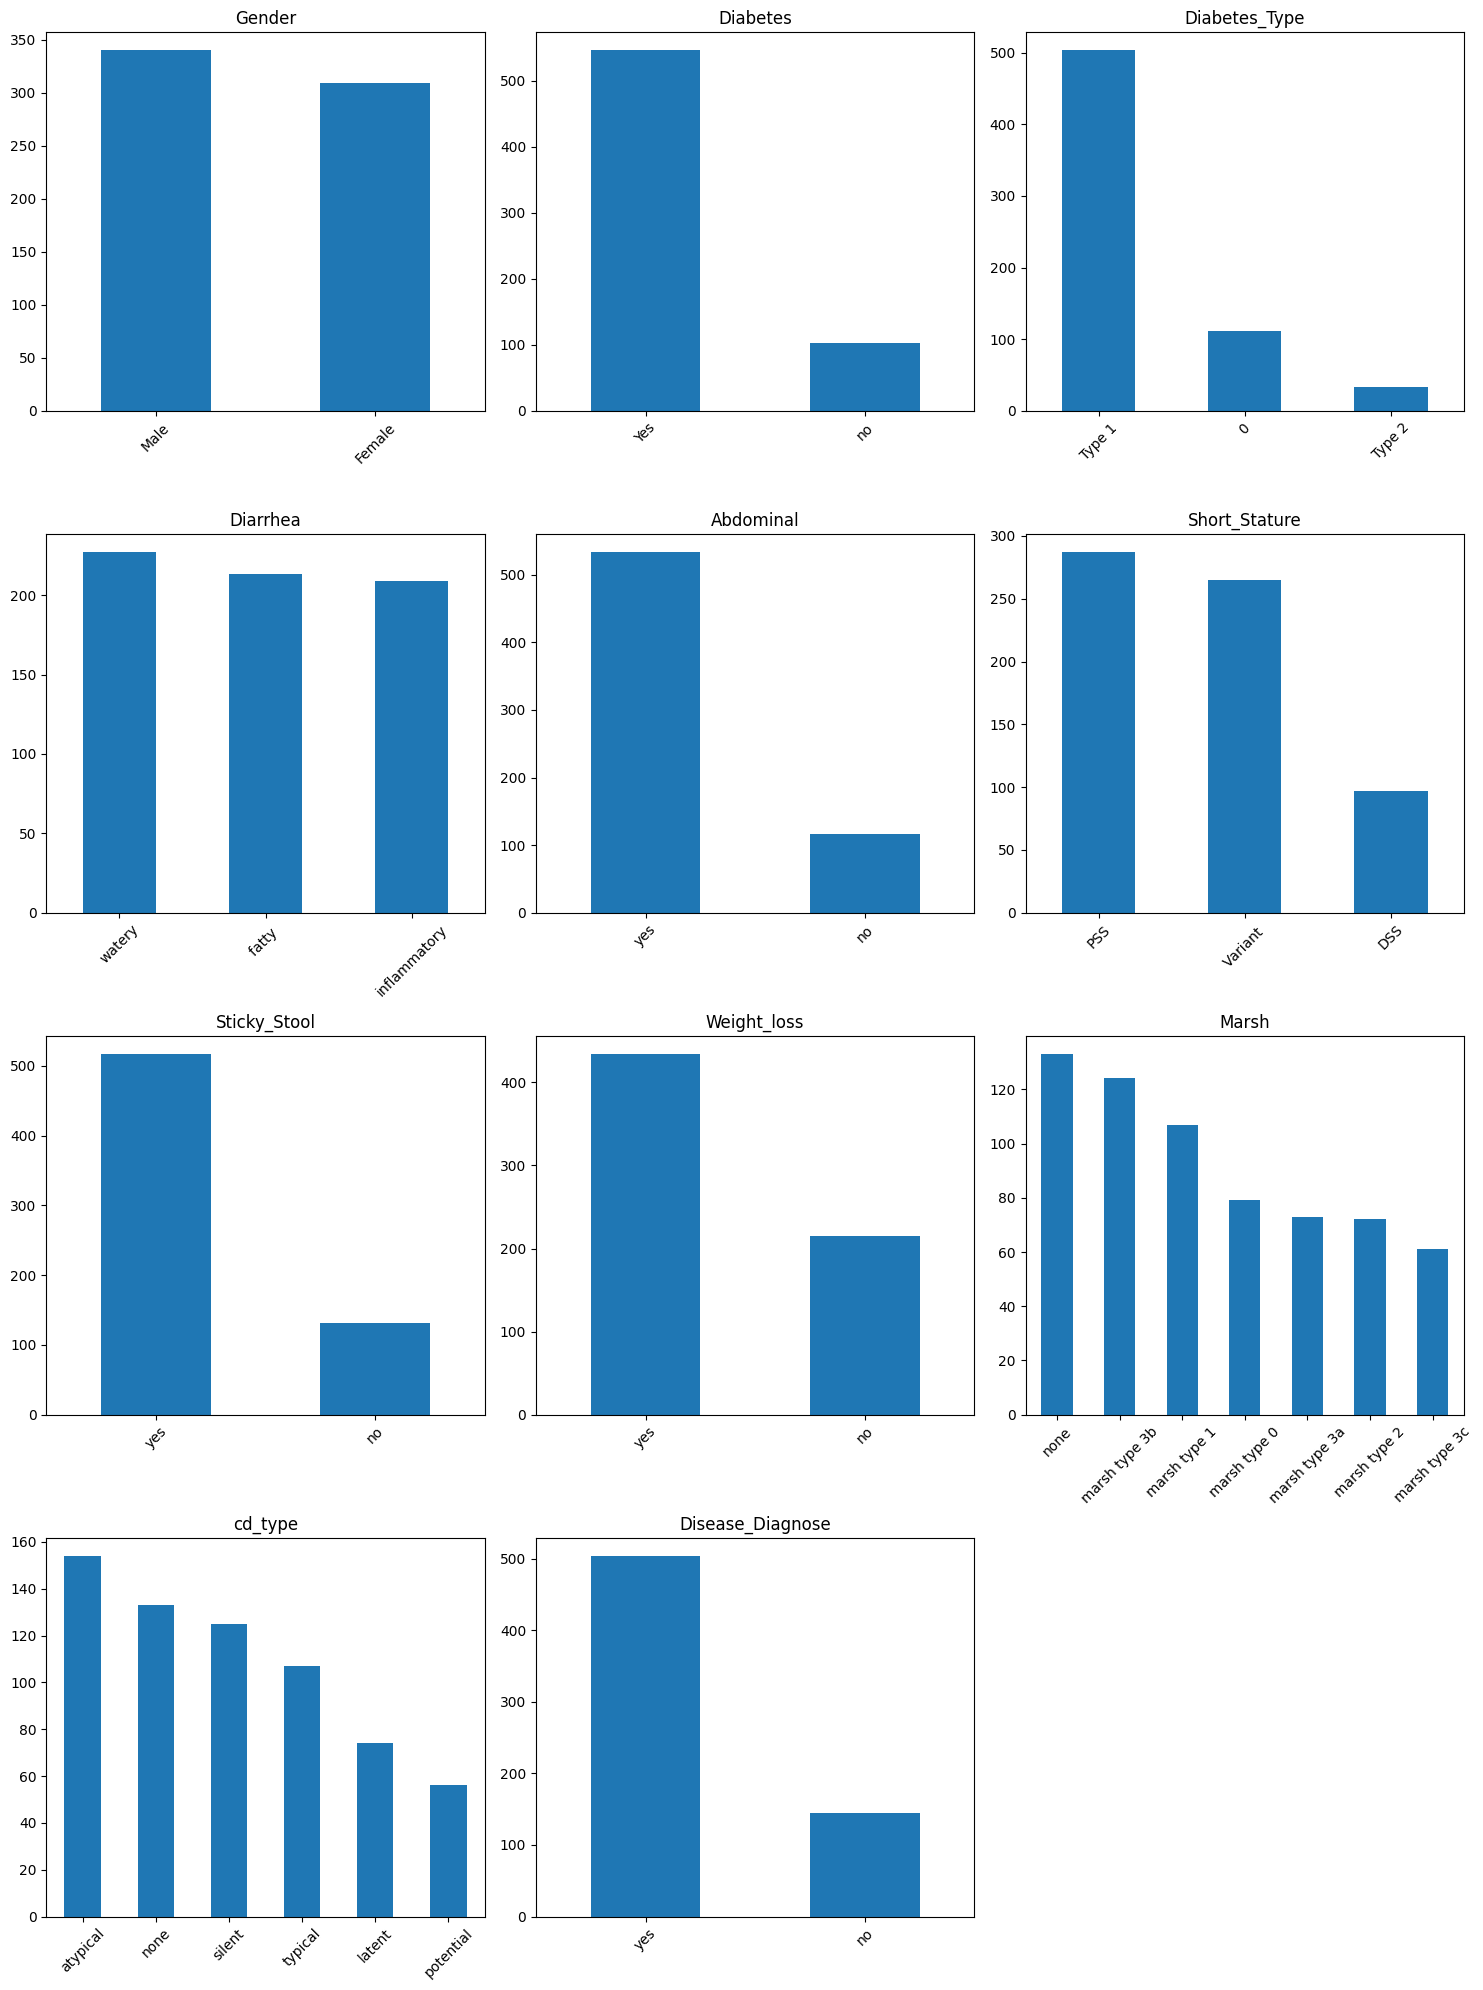

In [34]:
n_features = len(df_cat.columns)
ncols = 3
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))
axes = axes.flatten()

for i, col in enumerate(df_cat.columns):
    df_cat[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


It's important to look at these distributions and identify variables that are not normally distributed. This could come back to bite ue when we create ML models if certain categories are over or underrepresented. 

Here, my concern is the Diabetes variable. Most of this data was collected from people with diabetes, which may influence other symptoms. I'm not sure that the rest of these variables are independent of someone having diabetes. We can't do a lot about that now, but it's something to keep in mind going forward.

Another **major** point of concern is the Disease_Diagnose variable. The occurance of celiac is about 1% globally, and in this dataset, 83% of the subjects have celiac. Since the proportion of people with celiac in this dataset is so much bigger than it should be, this is not an accurate representation of the population. 

# Correlation Matricies

Visualizing Correlations Between Variables: 
- using a correlation matrix for numeric variables
- using Cramer's V to measure correlation between categorical variables (derived from chi-square)
- using correlation ratio for correlation between categorical and numeric variables (how much of the numeric variation can be explained by the categorical variable's groups)

<Axes: >

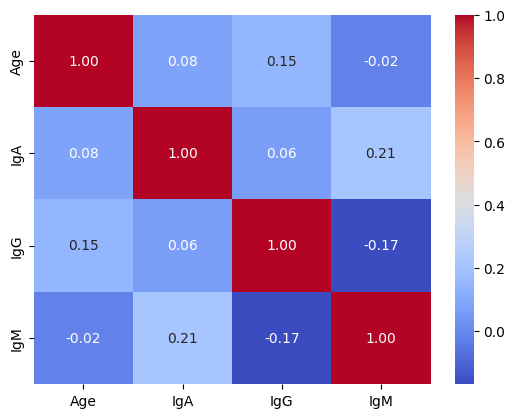

In [35]:
# correlation matrix for numeric variables
correlation_matrix = df_num.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')

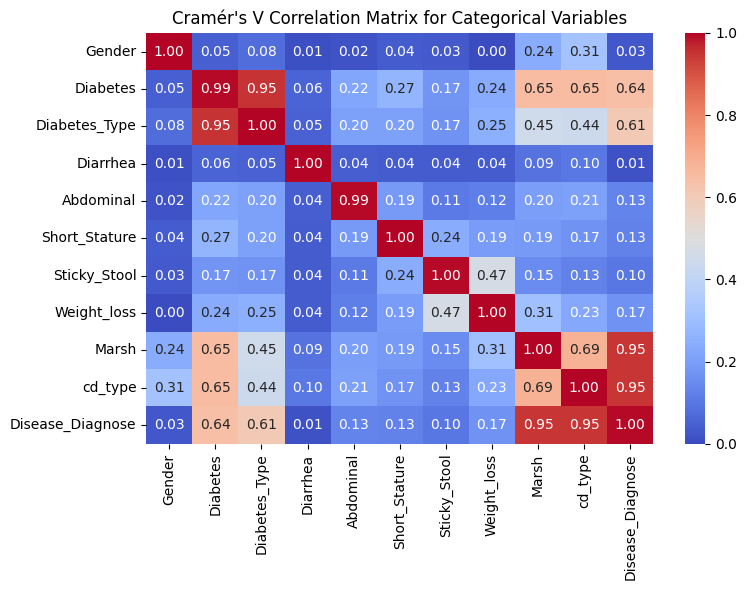

In [36]:
# cramer's v for categorical variables
cramers_matrix = pd.DataFrame(
    np.zeros((len(df_cat.columns), len(df_cat.columns))),
    columns=df_cat.columns,
    index=df_cat.columns
)

for col1 in df_cat.columns:
    for col2 in df_cat.columns:
        contingency_table = pd.crosstab(df_cat[col1], df_cat[col2])
        chi2 = chi2_contingency(contingency_table)[0]
        n = contingency_table.sum().sum()
        phi2 = chi2 / n
        r, k = contingency_table.shape
        phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
        rcorr = r - ((r - 1) ** 2) / (n - 1)
        kcorr = k - ((k - 1) ** 2) / (n - 1)
        cramers_matrix.loc[col1, col2] = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

plt.figure(figsize=(8,6))
sns.heatmap(cramers_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=0) 
plt.title("Cramér's V Correlation Matrix for Categorical Variables")
plt.tight_layout()
plt.show()


Mixed results here - definitely reinforces that I have to drop marsh and cd_type. marsh almost is disease_diagnose, which makes sense. Same with diabetes and diabetes_type - we can drop diabetes. Interesting that gender has a much higher correlation with marsh and cd_type than it does with disease_diagnose.

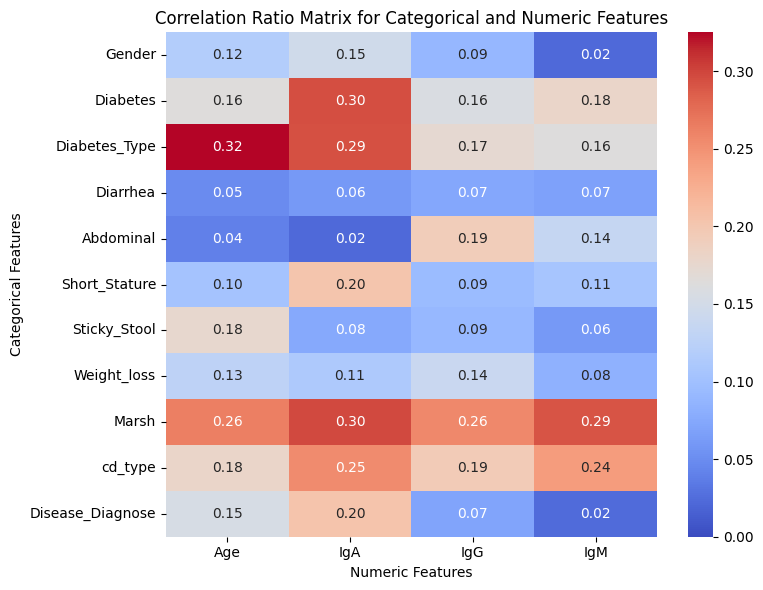

In [37]:
# correlation ratio
mix_matrix = pd.DataFrame(
    np.zeros((len(df_cat.columns), len(df_num.columns))), 
    columns = df_num.columns,
    index = df_cat.columns
)
for cat_col in df_cat.columns:
    for num_col in df_num.columns:
        categories = np.array(df_cat[cat_col].astype(str))
        values = np.array(df_num[num_col])

        # handle nan values
        mask = ~np.isnan(values) | pd.isna(values)
        categories = categories[mask]
        values = values[mask]

        overall_mean = np.mean(values)
        ssw = 0

        for category in np.unique(categories):
            group = values[categories == category]
            ssw += np.sum((group - np.mean(group)) ** 2)

        sst = np.sum((values - overall_mean) ** 2)

        if sst == 0:
            mix_matrix.loc[cat_col, num_col] = 0.0
        else:
            mix_matrix.loc[cat_col, num_col] = np.sqrt(1 - (ssw / sst))

plt.figure(figsize=(8, 6))
sns.heatmap(mix_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=0)
plt.title("Correlation Ratio Matrix for Categorical and Numeric Features")
plt.xlabel("Numeric Features")
plt.ylabel("Categorical Features")
plt.tight_layout() 
plt.show()

No super high correlations - means there is no categorical variable perfectly explained by a numeric one. This is good, and it also tells us to look more into the pairings with a higher correlation.

# Crosstabs

Now, to look more specifically at diabetes type and celiac disease:

<Axes: xlabel='Disease_Diagnose', ylabel='Diabetes_Type'>

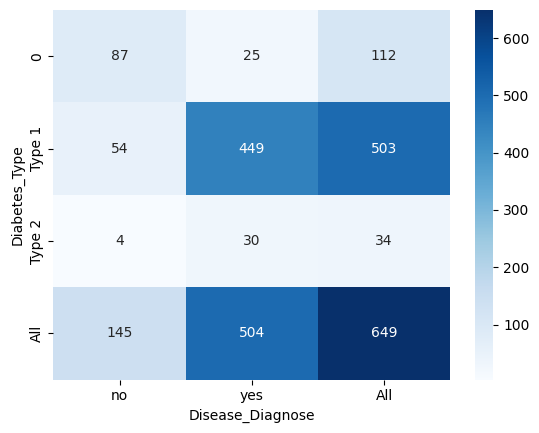

In [38]:
table = pd.crosstab(df['Diabetes_Type'], df['Disease_Diagnose'], margins=True)
sns.heatmap(table, annot=True, fmt="d", cmap='Blues')

About 6% of people with T1D have celiac. Compared to the global average of 1%, this is much higher. Elevated risk of celiac disease because both are autoimmune diseases (known genetic link). There is no association or elevated risk with T2D.

# Data Cleaning

Before we build models, we need to drop some features to reduce multicollinearity and data leakage.

In [39]:
df = df.drop(columns=['Marsh', 'cd_type', 'Diabetes'])

In [40]:
df.shape

(649, 12)

In [41]:
df.head()

,Age,Gender,Diabetes_Type,Diarrhea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Disease_Diagnose
0,10,Male,Type 1,inflammatory,yes,PSS,no,no,1.30,10.0,1.00,yes
1,9,Male,Type 1,fatty,yes,PSS,no,no,1.50,12.5,1.30,yes
2,8,Female,Type 1,watery,yes,Variant,yes,yes,0.40,8.0,0.50,yes
3,10,Male,Type 1,watery,yes,PSS,no,no,0.98,9.0,0.66,yes
4,9,Male,Type 1,fatty,yes,PSS,no,no,1.00,10.5,1.10,yes


# Moving on to the rest of the data prep:

Since only 4 of our variables are numeric, we will have to one-hot encode the rest of the 'object' variables. This will create several binary variables for each categorical variable. The 'Diabetes Type' variable has three levels, Type I, Type II, and None. Three binary variables need to be created for this, one binary indicator for Type I, one for Type II, and one for none. We are going to use pandas to do this automatically. Before we can start, we first need to convert some of the variables with only two levels to binary variables. 

The variables that need to be converted to binary are all of the yes/no variables in the dataframe.

Creating one binary variable instead of one-hot encoding and making multiple binary variables is more efficient and will make modeling just a little bit easier. 

This will apply to the 'Diabetes', 'Abdominal', 'Sticky_Stool', 'Weight_loss', and 'Disease_Diagnose' variables.

First, notice that in the original dataset, some of the answers are Yes with a capital Y and some are lowercase. We'll convert all of the y/n variabes to lowercase to prevent any case-sensitivity issues.

In [42]:
df['Abdominal'] = df['Abdominal'].str.lower()
df['Sticky_Stool'] = df['Sticky_Stool'].str.lower()
df['Weight_loss'] = df['Weight_loss'].str.lower()
df['Disease_Diagnose'] = df['Disease_Diagnose'].str.lower()

In [43]:
df.head()

,Age,Gender,Diabetes_Type,Diarrhea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Disease_Diagnose
0,10,Male,Type 1,inflammatory,yes,PSS,no,no,1.30,10.0,1.00,yes
1,9,Male,Type 1,fatty,yes,PSS,no,no,1.50,12.5,1.30,yes
2,8,Female,Type 1,watery,yes,Variant,yes,yes,0.40,8.0,0.50,yes
3,10,Male,Type 1,watery,yes,PSS,no,no,0.98,9.0,0.66,yes
4,9,Male,Type 1,fatty,yes,PSS,no,no,1.00,10.5,1.10,yes


In [44]:
df['Abdominal'] = np.where(df['Abdominal'] == 'yes', 1, 0)
df["Sticky_Stool"] = np.where(df["Sticky_Stool"] == 'yes', 1, 0)
df["Weight_loss"] = np.where(df["Weight_loss"] == 'yes', 1, 0)
df["Disease_Diagnose"] = np.where(df["Disease_Diagnose"] == 'yes', 1, 0)
df["Gender"] = np.where(df["Gender"] == 'Male', 1, 0)

In [45]:
df.head()

,Age,Gender,Diabetes_Type,Diarrhea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Disease_Diagnose
0,10,1,Type 1,inflammatory,1,PSS,0,0,1.30,10.0,1.00,1
1,9,1,Type 1,fatty,1,PSS,0,0,1.50,12.5,1.30,1
2,8,0,Type 1,watery,1,Variant,1,1,0.40,8.0,0.50,1
3,10,1,Type 1,watery,1,PSS,0,0,0.98,9.0,0.66,1
4,9,1,Type 1,fatty,1,PSS,0,0,1.00,10.5,1.10,1


Since there are only two options for Gender, we will code Male as 1 and Female as 0

Time to one-hot encode all of our categorical features! We will use one of the pandas methods, get_dummies. This will only apply to the object datatypes, so we don't need to repeat it for every variable we want to encode. I am going to overwrite our original dataframe with the one-hot encoded variables.

In [46]:
df = pd.get_dummies(df)

In [47]:
df.shape

(649, 18)

In [48]:
df.head()

,Age,Gender,Abdominal,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Disease_Diagnose,Diabetes_Type_0,Diabetes_Type_Type 1,Diabetes_Type_Type 2,Diarrhea_fatty,Diarrhea_inflammatory,Diarrhea_watery,Short_Stature_DSS,Short_Stature_PSS,Short_Stature_Variant
0,10,1,1,0,0,1.30,10.0,1.00,1,False,True,False,False,True,False,False,True,False
1,9,1,1,0,0,1.50,12.5,1.30,1,False,True,False,True,False,False,False,True,False
2,8,0,1,1,1,0.40,8.0,0.50,1,False,True,False,False,False,True,False,False,True
3,10,1,1,0,0,0.98,9.0,0.66,1,False,True,False,False,False,True,False,True,False
4,9,1,1,0,0,1.00,10.5,1.10,1,False,True,False,True,False,False,False,True,False


The first thing we are going to do is split the data into three pieces: a training set, a test set, and a validation set. The training set is what we will train the data on. This set will inevitably be run through the model multiple times, as we fine tune all the parameters. The test set will be new data presented to the trained model. We will evaluate each model on how it handles the test data. Lastly, we have the validation set. This piece of data can only be used **once**. We will only use this once we've selected a final model and have finished fine tuning the parameters.

First, we will separate the label, the disease_diagnosis column, from the rest of the features in order to prevent the models from accessing the label data. Next, we will split the data into a training and a test set. We will use 20% of the data for our test set and the rest for our training set. 

In [49]:
y = df['Disease_Diagnose']
x = df.drop('Disease_Diagnose', axis=1)

Let's discuss some of the parameters in the next fuction call. First, we are using x as our data and y as our label (what we're trying to predict). 

The test_size parameter is where we section out 0.2 of the data for our test set. The random_state parameter is setting a seed so the same split of the data will be done every call. This will later allow us to directly compare models trained on the same split of data. 

Stratify=y is maintaining the spread of the label (ratio of celiacs to non celiacs) in the training, test, and validation sets.

In [50]:
X_main, X_test, y_main, y_test = train_test_split(x, y, test_size=0.2, stratify = y, random_state=42)

Now we have a training set that is 80% of the data and a test set that is 20% of the data. 

Next, we are going to split the data again to create our validation set. We are splitting X_main and y_main into two more groups - the final training set and the validation set. We will be left with a validation set that is 10% of the initial dataset and a training set that is 70% of the initial dataset.

In [51]:
X_train, X_val, y_train, y_val = train_test_split(X_main, y_main, test_size=0.125, stratify=y_main, random_state=42)

In [52]:
X_train.shape, X_val.shape, X_test.shape

((454, 17), (65, 17), (130, 17))

# Logistic Regression:

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [54]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [55]:
coefficients = log_model.coef_
intercept = log_model.intercept_

print(f"Coefficients: {coefficients}")
print(f"Intercept: {intercept}")

Coefficients: [[ 0.071435    0.21200992  0.40068322  0.11100364  0.1670212  -0.20935428
  -0.13255643  0.77573206 -1.83696005  1.45742365  0.3571886   0.1750595
  -0.09813227 -0.09927502  0.45653032 -0.08385211 -0.395026  ]]
Intercept: [0.01572702]


In [56]:
log_model.predict(X_test)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1])

In [57]:
y_pred_log = log_model.predict(X_test)
# evaluate the model
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.75      0.62      0.68        29
           1       0.90      0.94      0.92       101

    accuracy                           0.87       130
   macro avg       0.82      0.78      0.80       130
weighted avg       0.86      0.87      0.86       130

[[18 11]
 [ 6 95]]


# Lasso

In [58]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

In [59]:
lasso_log = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=1000)
lasso_log.fit(X_train, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [60]:
y_pred_lasso = lasso_log.predict(X_test)
mse = mean_squared_error(y_test, y_pred_lasso)
print(f"Lasso Coefficients: {lasso_log.coef_}")

Lasso Coefficients: [[ 0.06968716  0.13366415  0.32360203  0.02833195  0.10670213 -0.16795397
  -0.10455255  0.82142356 -2.26595929  1.12773046  0.          0.22172225
   0.          0.          0.51019193  0.         -0.23491359]]


In [61]:
print(classification_report(y_test, y_pred_lasso))
print(confusion_matrix(y_test, y_pred_lasso))

              precision    recall  f1-score   support

           0       0.73      0.66      0.69        29
           1       0.90      0.93      0.92       101

    accuracy                           0.87       130
   macro avg       0.82      0.79      0.80       130
weighted avg       0.87      0.87      0.87       130

[[19 10]
 [ 7 94]]


In [62]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lasso_log.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
print(feature_importance)

                   feature  coefficient
8          Diabetes_Type_0    -2.265959
9     Diabetes_Type_Type 1     1.127730
7                      IgM     0.821424
14       Short_Stature_DSS     0.510192
2                Abdominal     0.323602
16  Short_Stature_Variant     -0.234914
11         Diarrhea_fatty      0.221722
5                      IgA    -0.167954
1                   Gender     0.133664
4              Weight_loss     0.106702
6                      IgG    -0.104553
0                      Age     0.069687
3             Sticky_Stool     0.028332
10    Diabetes_Type_Type 2     0.000000
12   Diarrhea_inflammatory     0.000000
13         Diarrhea_watery     0.000000
15       Short_Stature_PSS     0.000000


# Random Forest

In [63]:
from sklearn.ensemble import RandomForestClassifier

In [64]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
# Feature importances
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(importance_df)

print(f"Accuracy: {rf.score(X_test, y_test):.3f}")

                   feature  importance
8          Diabetes_Type_0    0.180330
9     Diabetes_Type_Type 1    0.139008
6                      IgG    0.116454
0                      Age    0.114619
5                      IgA    0.108321
7                      IgM    0.099227
1                   Gender    0.026700
11         Diarrhea_fatty     0.026535
4              Weight_loss    0.026400
13         Diarrhea_watery    0.025998
2                Abdominal    0.025389
12   Diarrhea_inflammatory    0.024537
15       Short_Stature_PSS    0.020669
3             Sticky_Stool    0.019079
10    Diabetes_Type_Type 2    0.017414
16  Short_Stature_Variant     0.016245
14       Short_Stature_DSS    0.013075
Accuracy: 0.862


Tune the model:

In [68]:
rf_best = RandomForestClassifier(random_state=42)

In [69]:
from sklearn.model_selection import RandomizedSearchCV

In [70]:
param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [15, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

random_search = RandomizedSearchCV(
    estimator=rf_best,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='recall',  # optimize for catching celiac patients
    n_jobs=1,
    random_state=42,
    verbose=2
)

This should take a few minutes to run

In [71]:
random_search.fit(X_train, y_train)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best F1 score: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   1.1s
[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   1.3s
[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   1.3s
[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   1.1s
[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   1.1s
[CV] END class_weight=balanced, max_depth=15, max_features=None, min_samples_leaf=2, min_samples_split=10, n_estimators=300; total time=   0.8s
[CV] END class_weight=balanced, max_depth=15, max_features=None, min_samples_leaf=2, min_samples_split=10, n_estimators=300; total time=   0.9s
[CV] END class_w

In [72]:
best_rf = random_search.best_estimator_

In [73]:
y_pred_tuned = best_rf.predict(X_test)
y_pred_proba_tuned = best_rf.predict_proba(X_test)[:, 1]

print("Tuned model performance:")
print(classification_report(y_test, y_pred_tuned))
print(confusion_matrix(y_test, y_pred_tuned))

Tuned model performance:
              precision    recall  f1-score   support

           0       0.85      0.59      0.69        29
           1       0.89      0.97      0.93       101

    accuracy                           0.88       130
   macro avg       0.87      0.78      0.81       130
weighted avg       0.88      0.88      0.88       130

[[17 12]
 [ 3 98]]


# SMOTE

We are going to try to improve predictions for people without celiac disease.

SMOTE, synthetic minority oversampling techniques, is helpful to balance an imbalanced dataset. It generates samples of the minority class to make the distribution balanced. 

In [74]:
from imblearn.over_sampling import SMOTE

In [75]:
smote_model = SMOTE(sampling_strategy='minority', random_state=42)
x_resampled, y_resampled = smote_model.fit_resample(X_train, y_train)
y_resampled.value_counts()


Disease_Diagnose
1    353
0    353
Name: count, dtype: int64

In [76]:
smote_log = LogisticRegression(max_iter=1000)
smote_log.fit(x_resampled, y_resampled)
smote_log_pred = smote_log.predict(X_test)
print(classification_report(y_test, smote_log_pred))
print(confusion_matrix(y_test, smote_log_pred))

              precision    recall  f1-score   support

           0       0.70      0.66      0.68        29
           1       0.90      0.92      0.91       101

    accuracy                           0.86       130
   macro avg       0.80      0.79      0.80       130
weighted avg       0.86      0.86      0.86       130

[[19 10]
 [ 8 93]]


Since this model performed worse than the last randomForest model, we can assume there are nonlinear patterns in the data that regression cannot measure. We are going to use a randomForest model on the oversampled data.

In [77]:
# Try different ratios
for ratio in [0.5, 0.7, 1.0]:
    print(f"\nSMOTE ratio: {ratio}")
    smote = SMOTE(sampling_strategy=ratio, random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        class_weight='balanced',
        random_state=42
    )
    
    rf.fit(X_train_smote, y_train_smote)
    y_pred = rf.predict(X_test)
    
    print(classification_report(y_test, y_pred))


SMOTE ratio: 0.5
              precision    recall  f1-score   support

           0       0.66      0.66      0.66        29
           1       0.90      0.90      0.90       101

    accuracy                           0.85       130
   macro avg       0.78      0.78      0.78       130
weighted avg       0.85      0.85      0.85       130


SMOTE ratio: 0.7
              precision    recall  f1-score   support

           0       0.68      0.66      0.67        29
           1       0.90      0.91      0.91       101

    accuracy                           0.85       130
   macro avg       0.79      0.78      0.79       130
weighted avg       0.85      0.85      0.85       130


SMOTE ratio: 1.0
              precision    recall  f1-score   support

           0       0.68      0.66      0.67        29
           1       0.90      0.91      0.91       101

    accuracy                           0.85       130
   macro avg       0.79      0.78      0.79       130
weighted avg       0

In [78]:
smote = SMOTE(sampling_strategy=1.0, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original training set: {y_train.value_counts()}")
print(f"After SMOTE: {pd.Series(y_train_smote).value_counts()}")


rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    #class_weight='balanced'
    random_state=42
)

Original training set: Disease_Diagnose
1    353
0    101
Name: count, dtype: int64
After SMOTE: Disease_Diagnose
1    353
0    353
Name: count, dtype: int64


In [79]:

rf_smote.fit(X_train_smote, y_train_smote)

y_pred = rf_smote.predict(X_test)
print("\nRandom Forest + SMOTE Performance:")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Random Forest + SMOTE Performance:
              precision    recall  f1-score   support

           0       0.68      0.66      0.67        29
           1       0.90      0.91      0.91       101

    accuracy                           0.85       130
   macro avg       0.79      0.78      0.79       130
weighted avg       0.85      0.85      0.85       130

[[19 10]
 [ 9 92]]


In [80]:
param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [15, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

rf = RandomForestClassifier(random_state=42)

# use recall as scoring to prioritize catching celiac cases - not penalizing false negatives as much
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='recall', 
    n_jobs=1,
    random_state=42,
    verbose=2
)

Again, give this one a few minutes

In [81]:
smote = SMOTE(sampling_strategy=1.0, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

random_search.fit(X_train_smote, y_train_smote)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation recall: {random_search.best_score_:.3f}")

# Evaluate on test set
best_rf_smote = random_search.best_estimator_
y_pred_tuned = best_rf_smote.predict(X_test)

print("Tuned RF + SMOTE Performance")
print(classification_report(y_test, y_pred_tuned))
print(confusion_matrix(y_test, y_pred_tuned))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   1.8s
[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   1.6s
[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   1.8s
[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   2.6s
[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   2.7s
[CV] END class_weight=balanced, max_depth=15, max_features=None, min_samples_leaf=2, min_samples_split=10, n_estimators=300; total time=   2.7s
[CV] END class_weight=balanced, max_depth=15, max_features=None, min_samples_leaf=2, min_samples_sp

SMOTE isn't helping enough to be effective. The best model so far was the previous tuned random forest model with a 99% recall on patients with celiac. It leads to some false positives, but that already happens with the blood test.

# SVM

SVM (support vector machine) models classify data by creating a decision boundary with as much space as possible from neighboring points. 

In [82]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [83]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(
    kernel='rbf',
    class_weight='balanced', 
    probability=True, 
    random_state=42)

In [84]:
svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [85]:
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.68      0.66      0.67        29
           1       0.90      0.91      0.91       101

    accuracy                           0.85       130
   macro avg       0.79      0.78      0.79       130
weighted avg       0.85      0.85      0.85       130

[[19 10]
 [ 9 92]]


Now tune

In [86]:
from sklearn.model_selection import GridSearchCV

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf', 'poly']
}

grid_svm = GridSearchCV(SVC(class_weight='balanced', probability=True), 
                        param_grid_svm, cv=5, scoring='f1')
grid_svm.fit(X_train_scaled, y_train)

,estimator,SVC(class_wei...bability=True)
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['rbf', 'poly']}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.1


In [87]:
best_svm = grid_svm.best_estimator_
y_pred_svm_tuned = best_svm.predict(X_test_scaled)
print("Tuned SVM Performance:")
print(classification_report(y_test, y_pred_svm_tuned))
print(confusion_matrix(y_test, y_pred_svm_tuned))

Tuned SVM Performance:
              precision    recall  f1-score   support

           0       0.76      0.66      0.70        29
           1       0.90      0.94      0.92       101

    accuracy                           0.88       130
   macro avg       0.83      0.80      0.81       130
weighted avg       0.87      0.88      0.87       130

[[19 10]
 [ 6 95]]


# XGBoost

In [88]:
from xgboost import XGBClassifier

In [89]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}") # xgboost uses this value to penalize errors on the minority class more

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # Handle imbalance
    random_state=42,
    eval_metric='logloss'
)

Scale pos weight: 0.29


In [90]:
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [91]:
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
print("XGBoost Performance:")
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Performance:
              precision    recall  f1-score   support

           0       0.64      0.72      0.68        29
           1       0.92      0.88      0.90       101

    accuracy                           0.85       130
   macro avg       0.78      0.80      0.79       130
weighted avg       0.85      0.85      0.85       130

[[21  8]
 [12 89]]


Random forest was still the best. It did have a higher false positive rate than some of the other models but that's ok in this context since it caught more people with celiac disease.

# Random forest wins!

Graph each model's performance:

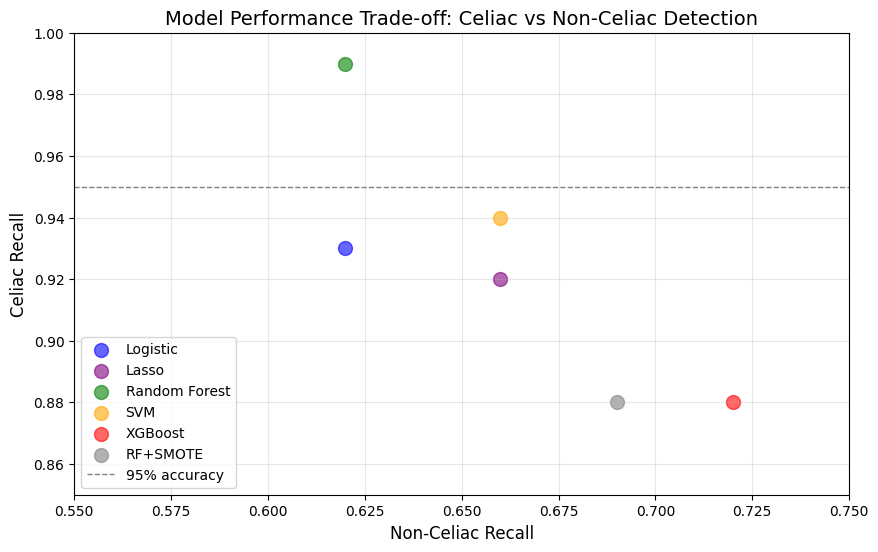

In [92]:
import matplotlib.pyplot as plt

models = ['Logistic', 'Lasso', 'Random Forest', 'SVM', 'XGBoost', 'RF+SMOTE']
celiac_recall = [0.93, 0.92, 0.99, 0.94, 0.88, 0.88]
non_celiac_recall = [0.62, 0.66, 0.62, 0.66, 0.72, 0.69]

plt.figure(figsize=(10, 6))
colors = ['blue', 'purple', 'green', 'orange', 'red', 'gray']
sizes = [100, 100, 100, 100, 100, 100] 

for i, model in enumerate(models):
    plt.scatter(non_celiac_recall[i], celiac_recall[i], 
                s=sizes[i], alpha=0.6, c=colors[i], label=model)

plt.xlabel('Non-Celiac Recall', fontsize=12)
plt.ylabel('Celiac Recall', fontsize=12)
plt.title('Model Performance Trade-off: Celiac vs Non-Celiac Detection', fontsize=14)
plt.axhline(y=0.95, color='gray', linestyle='--', linewidth=1, label='95% accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([0.55, 0.75])
plt.ylim([0.85, 1.0])
plt.show()

Now, to validate the final model.

In [93]:
best_model = best_rf
y_final_pred = best_model.predict(X_val)
y_final_proba = best_model.predict_proba(X_val)[:, 1]
print(classification_report(y_val, y_final_pred))
print(confusion_matrix(y_val, y_final_pred))


              precision    recall  f1-score   support

           0       1.00      0.73      0.85        15
           1       0.93      1.00      0.96        50

    accuracy                           0.94        65
   macro avg       0.96      0.87      0.90        65
weighted avg       0.94      0.94      0.93        65

[[11  4]
 [ 0 50]]


Last, explain feature importance using SHAP values

In [94]:
import shap

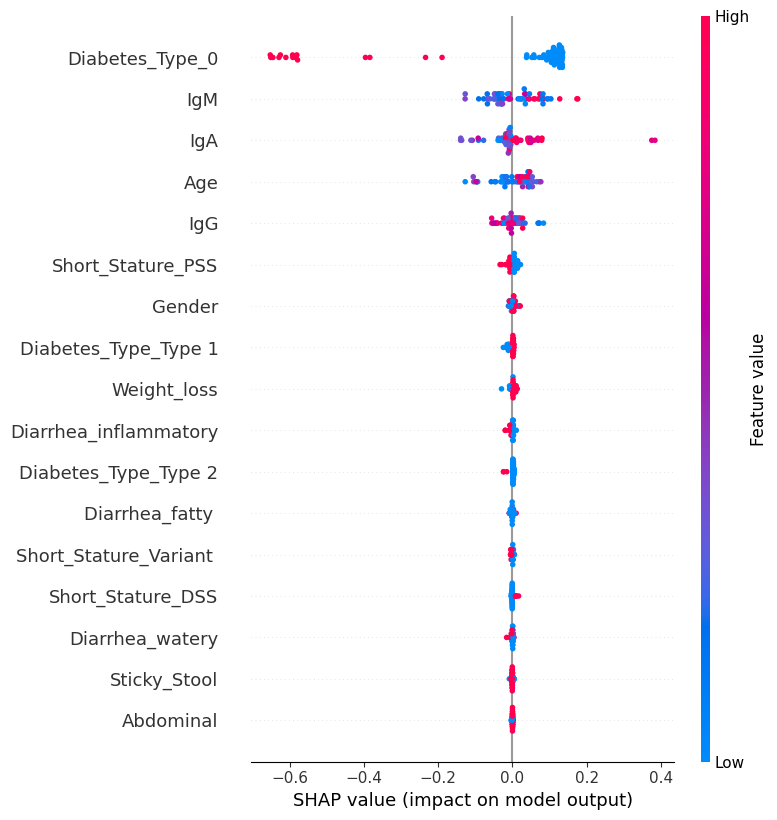

In [95]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_val)

shap_values_array = shap_values.values
if len(shap_values_array.shape) == 3:
   
    shap_values_celiac = shap_values_array[:, :, 1]
else:
    shap_values_celiac = shap_values_array
shap.summary_plot(shap_values_celiac, X_val)